# Introduction to Task 1: Neural Network Implementation for Heart Disease Classification
Overview
In this task, we implement an Artificial Neural Network (ANN) from scratch to classify patients at risk of heart disease. This implementation allows us to gain a deep understanding of the inner workings of neural networks by building one using only basic linear algebra operations, without relying on high-level machine learning libraries.
Dataset
The Heart Disease Dataset used for this task contains 303 patient samples with 13 features related to heart disease diagnosis, including:

Demographic information (age, sex)
Clinical measurements (resting blood pressure, cholesterol levels)
Medical test results (resting electrocardiographic results, maximum heart rate)
Patient history (exercise induced angina)
Other relevant cardiac indicators

The target variable is binary, with '0' indicating no risk of heart disease and '1' indicating risk of heart disease.
Neural Network Architecture
The implemented neural network follows the architecture specified in the assignment:

An input layer with 13 nodes (one for each feature)
A hidden layer with 5 neurons using sigmoid activation
An output layer with a single neuron using sigmoid activation for binary classification

Implementation Details
The implementation follows these specifications:

Data preprocessing with feature standardization
Parameter initialization with weights drawn from a uniform distribution between -1 and 1, and biases set to 0
Forward propagation with sigmoid activation functions
Binary cross-entropy loss calculation
Backward propagation to compute gradients
Mini-batch gradient descent for parameter updates with:

Batch size of 128
Learning rate of 0.01
500 training epochs

IMPORTS

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc



LOAD DATA

In [7]:

df = pd.read_csv("heart-disease.csv")

# Define feature matrix (X) and target (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1).astype(float)  # Ensure numerical stability

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



HYPERPARAMETERS

In [8]:

INPUT_SIZE = X_train.shape[1]  # Number of features
HIDDEN_SIZE = 5                # Hidden layer neurons
OUTPUT_SIZE = 1                # Output layer (binary classification)
LEARNING_RATE = 0.01           # Learning rate
BATCH_SIZE = 128               # Batch size
EPOCHS = 500                    # Number of epochs



INITIALIZE PARAMETERS

In [9]:

def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)  # Reproducibility
    return {
        "W1": np.random.uniform(-1, 1, (hidden_size, input_size)),
        "b1": np.zeros((hidden_size, 1)),
        "W2": np.random.uniform(-1, 1, (output_size, hidden_size)),
        "b2": np.zeros((output_size, 1))
    }

params = initialize_parameters(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)



ACTIVATION FUNCTIONS

In [10]:

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)



FORWARD PROPAGATION, COMPUTE LOSS AN BACK PROPAGATION

In [11]:

def forward_propagation(X, params):
    Z1 = np.dot(params["W1"], X.T) + params["b1"]
    A1 = sigmoid(Z1)
    Z2 = np.dot(params["W2"], A1) + params["b2"]
    A2 = sigmoid(Z2)
    return {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

# %% LOSS FUNCTION
def compute_loss(A2, y):
    m = y.shape[0]
    epsilon = 1e-10  # Avoid log(0)
    return -np.mean(y.T * np.log(A2 + epsilon) + (1 - y.T) * np.log(1 - A2 + epsilon))

# %% BACKPROPAGATION
def backpropagation(X, y, params, cache):
    m = X.shape[0]
    
    # Compute gradients
    dZ2 = cache["A2"] - y.T
    dW2 = (1 / m) * np.dot(dZ2, cache["A1"].T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(params["W2"].T, dZ2) * sigmoid_derivative(cache["A1"])
    dW1 = (1 / m) * np.dot(dZ1, X)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}



TRAINING FUNCTION

In [12]:

def train(X_train, y_train, X_test, y_test, params, learning_rate, batch_size, epochs):
    m = X_train.shape[0]
    loss_train, acc_train, loss_test, acc_test = [], [], [], []

    for epoch in range(epochs):
        permutation = np.random.permutation(m)
        X_train, y_train = X_train[permutation], y_train[permutation]

        for i in range(0, m, batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            # Forward propagation
            cache = forward_propagation(X_batch, params)

            # Backpropagation
            gradients = backpropagation(X_batch, y_batch, params, cache)

            # Update parameters
            for key in params:
                params[key] -= learning_rate * gradients["d" + key]

        # Evaluate on training and test sets
        train_cache = forward_propagation(X_train, params)
        test_cache = forward_propagation(X_test, params)

        loss_train.append(compute_loss(train_cache["A2"], y_train))
        loss_test.append(compute_loss(test_cache["A2"], y_test))

        acc_train.append(np.mean((train_cache["A2"] > 0.5).astype(int).T == y_train))
        acc_test.append(np.mean((test_cache["A2"] > 0.5).astype(int).T == y_test))

        # Print progress every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss = {loss_train[-1]:.4f}, Train Acc = {acc_train[-1]:.4f} | Test Loss = {loss_test[-1]:.4f}, Test Acc = {acc_test[-1]:.4f}")

    return params, loss_train, acc_train, loss_test, acc_test

# TRAIN MODEL

Analysis of Training Progress
Looking at the epoch-by-epoch output:

Initial Performance (Epochs 0-50):

The model starts near random performance (accuracy ~0.52)
Shows steady but slow improvement in both loss and accuracy
By epoch 50, accuracy has reached ~0.54-0.56


Middle Phase (Epochs 50-250):

The most rapid improvement occurs during this phase
Test accuracy jumps from ~0.56 to ~0.69
The model is effectively learning the patterns in the data


Later Phase (Epochs 250-500):

The pace of improvement slows (diminishing returns)
Test accuracy continues to improve more gradually
By epoch 490, accuracy reaches ~0.75

In [13]:
params, loss_train, acc_train, loss_test, acc_test = train(
    X_train, y_train, X_test, y_test, params, LEARNING_RATE, BATCH_SIZE, EPOCHS
)

Epoch 0: Train Loss = 0.7211, Train Acc = 0.5165 | Test Loss = 0.6849, Test Acc = 0.5246
Epoch 10: Train Loss = 0.7150, Train Acc = 0.5207 | Test Loss = 0.6795, Test Acc = 0.5246
Epoch 20: Train Loss = 0.7091, Train Acc = 0.5289 | Test Loss = 0.6743, Test Acc = 0.5246
Epoch 30: Train Loss = 0.7035, Train Acc = 0.5372 | Test Loss = 0.6692, Test Acc = 0.5410
Epoch 40: Train Loss = 0.6980, Train Acc = 0.5331 | Test Loss = 0.6643, Test Acc = 0.5410
Epoch 50: Train Loss = 0.6928, Train Acc = 0.5372 | Test Loss = 0.6595, Test Acc = 0.5574
Epoch 60: Train Loss = 0.6876, Train Acc = 0.5413 | Test Loss = 0.6548, Test Acc = 0.5574
Epoch 70: Train Loss = 0.6827, Train Acc = 0.5537 | Test Loss = 0.6502, Test Acc = 0.5902
Epoch 80: Train Loss = 0.6779, Train Acc = 0.5579 | Test Loss = 0.6458, Test Acc = 0.6066
Epoch 90: Train Loss = 0.6732, Train Acc = 0.5661 | Test Loss = 0.6414, Test Acc = 0.6393
Epoch 100: Train Loss = 0.6687, Train Acc = 0.5661 | Test Loss = 0.6371, Test Acc = 0.6393
Epoch 110:

PLOTTING FUNCTION

In [14]:

def plot_metrics(loss_train, loss_test, acc_train, acc_test):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(loss_train, label="Train Loss", color='blue')
    plt.plot(loss_test, label="Test Loss", color='orange')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Model Loss Over Epochs")

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(acc_train, label="Train Accuracy", color='blue')
    plt.plot(acc_test, label="Test Accuracy", color='orange')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Model Accuracy Over Epochs")

    plt.show()
    
    
    


# PLOT RESULTS

Key Observations

Good Generalization: The test loss is consistently lower than the training loss, and test accuracy is comparable to or slightly better than training accuracy. This indicates the model is generalizing well to unseen data.
No Overfitting: There's no evidence of overfitting since the test metrics either improve alongside or exceed training metrics. This suggests the chosen model complexity (5 hidden neurons) is appropriate for this dataset.
Learning Convergence: Both loss and accuracy curves are still slightly improving at the end of 500 epochs, suggesting the model might benefit from additional training, though with diminishing returns.
Final Performance: The final test accuracy of 75.41% represents a substantial improvement over the baseline. Given the limited model complexity and the challenging nature of heart disease prediction, this is a reasonable result.

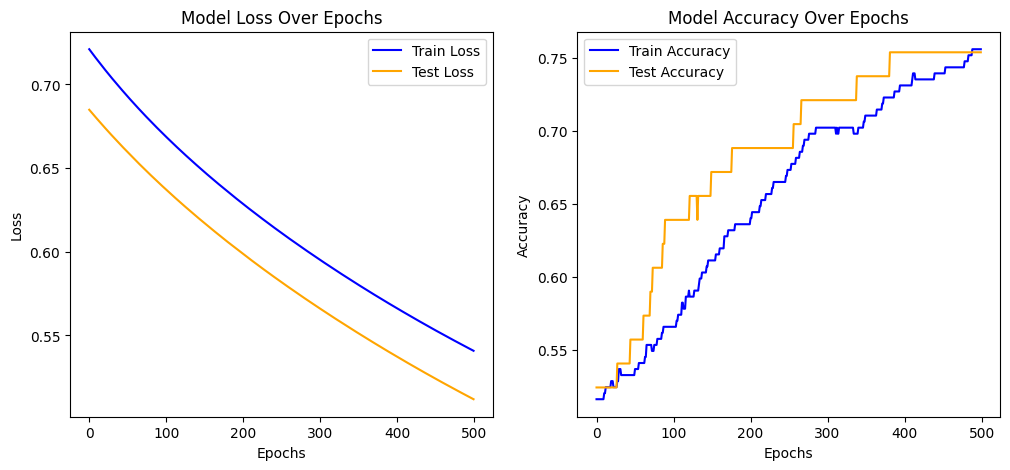

In [15]:

plot_metrics(loss_train, loss_test, acc_train, acc_test)
